In [ ]:
!pip install jaxopt

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jaxopt import LBFGS

In [ ]:
seed = 0
key = jax.random.key(seed)
jax.config.update("jax_enable_x64", True)

In [ ]:
def project(v,n):
  return v-jnp.dot(v,n)/jnp.dot(n,n)*n

def log_r(x, xi, nx, y, xi_prime, ny, beta):
  phi = 0.5*jnp.log(jnp.dot(nx,nx)/jnp.dot(ny,ny))
  gaussian_term = (jnp.linalg.norm(x) + jnp.linalg.norm(y))*(jnp.linalg.norm(x)-jnp.linalg.norm(y))
  proposal_term = (jnp.linalg.norm(xi)+jnp.linalg.norm(xi_prime))*(jnp.linalg.norm(xi)-jnp.linalg.norm(xi_prime))
  return phi + 0.5 * gaussian_term + (1 / (2 * beta**2)) * proposal_term

def compute_reverse(x, y, n, beta):
    return project(x-jnp.sqrt(1-beta**2)*y, n)

In [ ]:
F = 1.1
mu2 = 6.2

def V_prime(x):
    return -F+x+mu2*(x**3-2*x**2+x)

In [ ]:
def manifold(d,z=0):

  x_0 = jnp.float64(1.1)
  tt = 100
  dt = tt/d
  dW = jnp.sqrt(dt)
  t0=dt

  def diffusion():
    return 0.2

  def drift(x):
    return -V_prime(x)

  def pathstep(x_i, rand_var):
    x_i += drift(x_i)*dt + diffusion()*dW*rand_var
    return x_i, x_i

  def F_full(x):
    end, sample_path = jax.lax.scan(pathstep, x_0 ,x)
    return end - z, sample_path

  def F(x):
    out, _ = F_full(x)
    return out

  def x0():
    def h(x):
      return 0.5*jnp.dot(x,x)
    c = 1e6
    def pen(x):
      final, _ = jax.lax.scan(pathstep,x_0,x)
      return c*(final-z)**2
    def J(x):
      return h(x) + pen(x)
    init = jnp.linspace(0,z/2,d)
    solver = LBFGS(fun=J,maxiter=100,tol=1e-3)
    solns = solver.run(init)
    return solns.params

  def nx0():
    return jax.grad(F,allow_int=True)(x0())

  def manifoldproject(x, n, tol=1e-3, maxiter=100):
    def f(val):
      a,i = val
      ff = lambda a: F(x + a * n)
      fff = ff(a)
      dff = jax.grad(ff)(a)
      return (a-fff/dff, i+1)
    def cond(val):
      a,i = val
      return jnp.logical_and(jnp.abs(F(x + a * n))>tol,i<maxiter)
    a,_ = jax.lax.while_loop(cond, f, (0.0,0))
    success = lambda a: jnp.abs(F(x + a * n))<tol
    return jnp.where(success(a), x + a * n, x)

  return F, x0, nx0, manifoldproject, F_full

In [ ]:
def PCN_paths(beta=0.1, d=jnp.int32(1e5), burnin=1000, N=0, z=0):
    F, x0, nx0, manifoldproject, F_full = manifold(d,z=z)
    keylist = jax.random.split(key, N+burnin)

    @jax.jit
    def sampleStep(carry, current_key):
        (x, nx, accs, it) = carry

        rho = jnp.sqrt(1-beta**2)
        xi = beta * project(jax.random.normal(current_key,shape=x.shape), nx)
        v = project((rho-1)*x, nx) + xi
        y = manifoldproject(x+v,nx)
        ny = jax.grad(F)(y)
        xi_prime = compute_reverse(x, y, ny, beta)
        R = log_r(x, xi, nx, y, xi_prime, ny, beta)
        acc = (jnp.log(jax.random.uniform(current_key)) < R)
        x = jnp.where(acc, y, x)
        nx = jnp.where(acc, ny, nx)
        accs += jnp.where(it>burnin,acc,0)
        it += 1
        return (x, nx, accs, it), (R,x)

    (eta, _, accs, _), (Rs,xs) = jax.lax.scan(sampleStep, (x0(), nx0(), 0, 0), keylist)
    _, path = F_full(eta)
    stats = [np.mean(Rs[burnin:]), accs/(N+burnin)]
    sample_path = np.array(path)
    plt.xlabel('timesteps')
    plt.ylabel('X_t')
    plt.title('AMOC Conditioned Sample Paths')
    plt.plot(range(len(sample_path)),sample_path)
    print('Accepted:', accs, 'out of', N+burnin)
    print('Error:', sample_path[-1]-z)

    return None

Accepted: 961 out of 1000
Error: 0.00030684701749330093
Accepted: 1059 out of 1100
Error: 0.0009061280728703954
Accepted: 1156 out of 1200
Error: 8.703770624507445e-06
Accepted: 1252 out of 1300
Error: 0.00036277786834562707


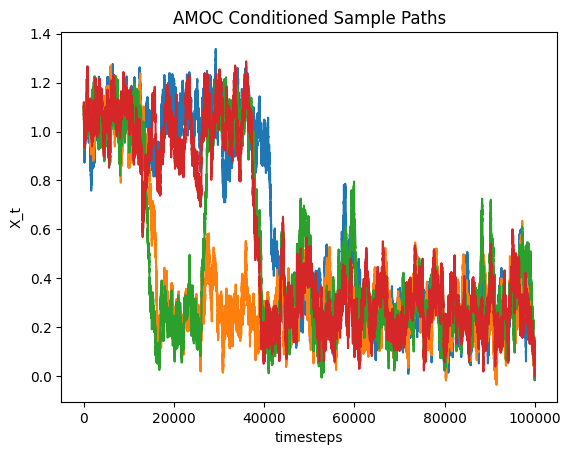

In [ ]:
PCN_paths()
PCN_paths(N=100)
PCN_paths(N=200)
PCN_paths(N=300)

In [ ]:
def PCN(beta=0.1, d=jnp.int32(1e5), burnin=1000, N=1000, z=0):
    F, x0, nx0, manifoldproject, F_full = manifold(d,z=z)
    keylist = jax.random.split(key, N+burnin)

    @jax.jit
    def sampleStep(carry, current_key):
        (x, nx, accs, it) = carry

        rho = jnp.sqrt(1-beta**2)
        xi = beta * project(jax.random.normal(current_key,shape=x.shape), nx)
        v = project((rho-1)*x, nx) + xi
        y = manifoldproject(x+v,nx)
        ny = jax.grad(F)(y)
        xi_prime = compute_reverse(x, y, ny, beta)
        R = log_r(x, xi, nx, y, xi_prime, ny, beta)
        acc = (jnp.log(jax.random.uniform(current_key)) < R)
        x = jnp.where(acc, y, x)
        nx = jnp.where(acc, ny, nx)
        accs += acc
        it += 1
        return (x, nx, accs, it), (R,x)

    (eta, _, accs, _), (Rs,xs) = jax.lax.scan(sampleStep, (x0(), nx0(), 0, 0), keylist)

    return np.array(xs[burnin:,:])

In [ ]:
noises = PCN()

In [ ]:
samplesize = noises.shape[0]
_,_,_,_,F_full = manifold(noises.shape[1])
idxs = []
for i in range(samplesize):
  _, samplepath = F_full(noises[i,:])
  for j in range(samplepath.shape[0]):
    if samplepath[j] <= 0.2:
      idxs.append(j)
      break

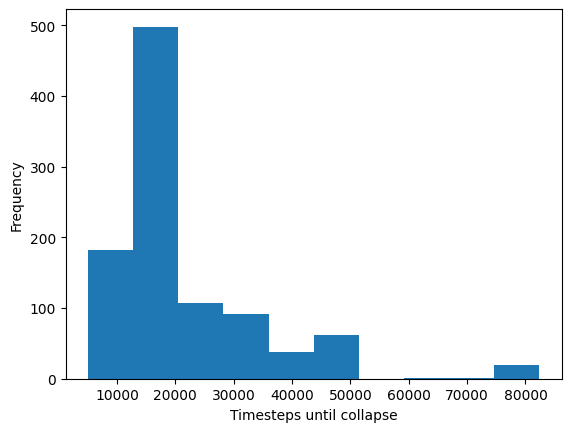

In [ ]:
plt.hist(idxs)
plt.xlabel('Timesteps until collapse')
plt.ylabel('Frequency')
plt.savefig('distribution.png')